In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (200, 5)

First 5 Rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [10]:
# Select features for clustering
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

print("Features selected for clustering:")
display(X.head())

Features selected for clustering:


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


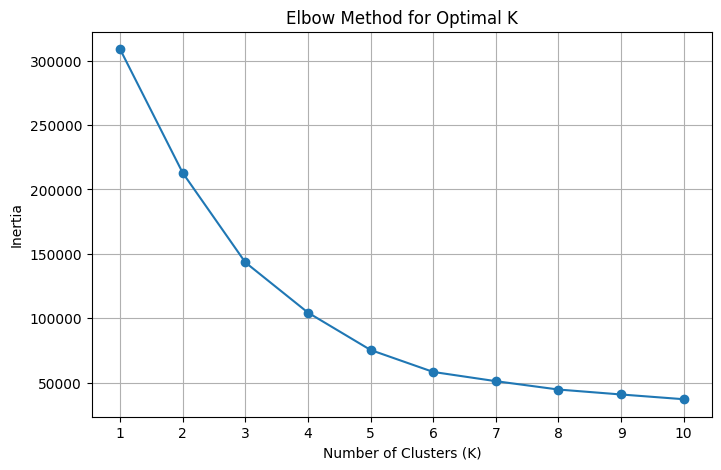

In [11]:
# Elbow Method to find the optimal number of clusters

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [12]:
# Apply K-Means clustering with 5 clusters

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

print("Customer Cluster Counts:")
print(df["Cluster"].value_counts().sort_index())

Customer Cluster Counts:
Cluster
0    23
1    79
2    39
3    36
4    23
Name: count, dtype: int64


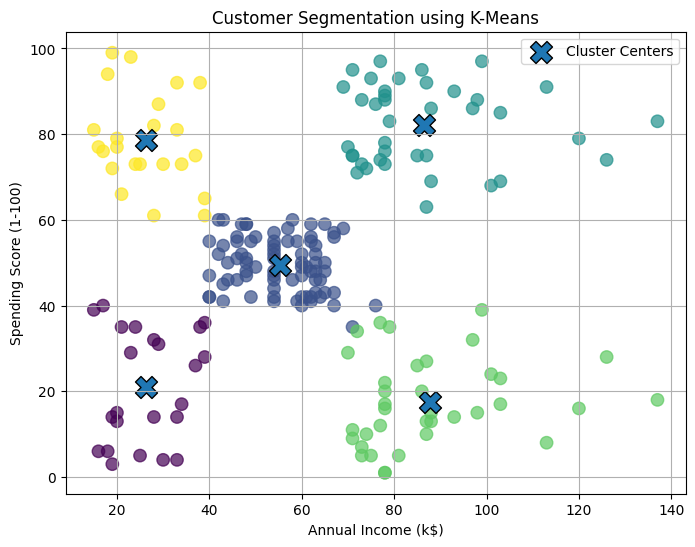

In [13]:
# Visualize customer clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=80,
    alpha=0.7
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 1],
    centers[:, 2],
    s=250,
    marker="X",
    edgecolor="black",
    label="Cluster Centers"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')


In [18]:
# Cluster characteristics
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

print("Cluster Characteristics:")
print(cluster_summary.round(2))

Cluster Characteristics:
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91


In [19]:
print("Customer Segmentation Summary")
print("-----------------------------")

for cluster in cluster_summary.index:
    age = cluster_summary.loc[cluster, "Age"]
    income = cluster_summary.loc[cluster, "Annual Income (k$)"]
    spending = cluster_summary.loc[cluster, "Spending Score (1-100)"]

    print(f"\nCluster {cluster}:")
    print(f"Average Age: {age:.2f}")
    print(f"Average Annual Income: {income:.2f} k$")
    print(f"Average Spending Score: {spending:.2f}")

Customer Segmentation Summary
-----------------------------

Cluster 0:
Average Age: 42.72
Average Annual Income: 55.30 k$
Average Spending Score: 49.52

Cluster 1:
Average Age: 32.69
Average Annual Income: 86.54 k$
Average Spending Score: 82.13

Cluster 2:
Average Age: 25.27
Average Annual Income: 25.73 k$
Average Spending Score: 79.36

Cluster 3:
Average Age: 41.11
Average Annual Income: 88.20 k$
Average Spending Score: 17.11

Cluster 4:
Average Age: 45.22
Average Annual Income: 26.30 k$
Average Spending Score: 20.91


In [20]:
print("Customer Segmentation Report")
print("----------------------------")

print("Cluster 0: Middle-aged customers with moderate income and moderate spending.")
print("Cluster 1: Customers with high income and high spending.")
print("Cluster 2: Younger customers with low income but high spending.")
print("Cluster 3: Customers with high income but low spending.")
print("Cluster 4: Older customers with low income and low spending.")

print("\nOverall Finding:")
print("K-Means clustering divided customers into 5 groups based on annual income and spending score.")

Customer Segmentation Report
----------------------------
Cluster 0: Middle-aged customers with moderate income and moderate spending.
Cluster 1: Customers with high income and high spending.
Cluster 2: Younger customers with low income but high spending.
Cluster 3: Customers with high income but low spending.
Cluster 4: Older customers with low income and low spending.

Overall Finding:
K-Means clustering divided customers into 5 groups based on annual income and spending score.
